# Financial Model Calibration using ANNs (CaNN, Calibration Neural Network) (SABR model)
###### This Jupyter Notebook implements the calibration framework proposed in "A neural network-based framework for financial model calibration", Liu et al. ([1]) building on "Pricing options and computing implied volatilities using neural networks", Liu et al. ([2]) as part of my master's thesis. It extends the implementation at https://github.com/Redmek/Pricing-options-and-computing-implied-volatilities-using-neural-networks and merges two seperate ANNs (one for option prices and one for implied volatilies) into a single network for fast calibration.

###### Author: Dominik Wirsig

# -------------------------------------------------------




## The framework consists of 3 Phases, i.e.:

### 1. Training (FORWARD PASS)
### 2. Prediction (FORWARD PASS)
### 3. Calibration (BACKWARD PASS)

# -------------------------------------------------------




Table of contents

### 1) Forward pass
###### a) Preperation
###### b) Data generation
###### c) Training Heston-IV-ANN
###### d) Prediction

### 2) Backward pass
###### a) Calibration of all 5 Heston parameters
###### b) Calibration of only 3 Heston parameters (kappa, v0 fixed)


# -------------------------------------------------------




# 1) Forward pass




## a) Preperation




In [54]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Updating scipy to use module QMC for Latin hypercube sampling
#!pip install scipy==1.7
from scipy.stats import qmc

# Pytorch imports
import torch
import torch.nn as nn
import torch.nn.functional as Fnn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR, LinearLR, OneCycleLR, LambdaLR

from scipy.optimize import differential_evolution

In [10]:
pip install pysabr

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Import both Lognormal and Normal SABR model classes
from pysabr import Hagan2002LognormalSABR
from pysabr import Hagan2002NormalSABR
from pysabr import hagan_2002_normal_sabr as sabr
from pysabr.helpers import year_frac_from_maturity_label

In [48]:
from pysabr import hagan_2002_normal_sabr as hagan_normal
from pysabr import Hagan2002NormalSABR


In [12]:
# run on GPU
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(device)

cuda


### Black-Scholes




In [99]:
def bs_price_call(S, K, T, t, r, sigma):
  """
  Black-Scholes call option value price related to PDE (2). Returns option's price.
  S:     spot price
  K:     strike price
  T:     time to maturity
  t:     spot time
  r:     interest rate
  sigma: volatility of underlying asset
  """

  # Boundary condition of Black-Sholes PDE (2)
  if T == t:
    return np.maximum(0, S - K)  
  # Solution of the PDE (2) on the open interval [t, T)
  else : 
    d1 = ( np.log(S / K) + (r + 0.5 * sigma ** 2) * (T-t) ) / (sigma * np.sqrt(T-t))
    d2 = d1 - sigma*np.sqrt(T-t)
    value = S * norm.cdf(d1) - K * np.exp(-r * (T-t)) * norm.cdf(d2) 
  
  return value

def bs_moneyness_call(moneyness, tau, r, sigma):
  """
  Same function as bs_price_call but in terms of moneyness. Returns V/K and 
  has S/K instead of two seperate paremeters S and K.
  moneyness: S/K
  Tau: time to maturity minus spot time
  r: interest rate
  sigma: volatility of underlying asset
  """

  d1 = ( np.log(moneyness) + (r + 0.5 * sigma ** 2) * (tau) ) / (sigma * np.sqrt(tau))
  d2 = d1 - sigma*np.sqrt(tau)
  value_moneyness = moneyness * norm.cdf(d1) - np.exp(-r * (tau)) * norm.cdf(d2) 
  
  return value_moneyness

C:\Users\Dominik\AppData\Local\Temp\ipykernel_4788\2592051303.py:17: RuntimeWarning: divide by zero encountered in log
  d1 = ( np.log(S / K) + (r + 0.5 * sigma ** 2) * (T-t) ) / (sigma * np.sqrt(T-t))


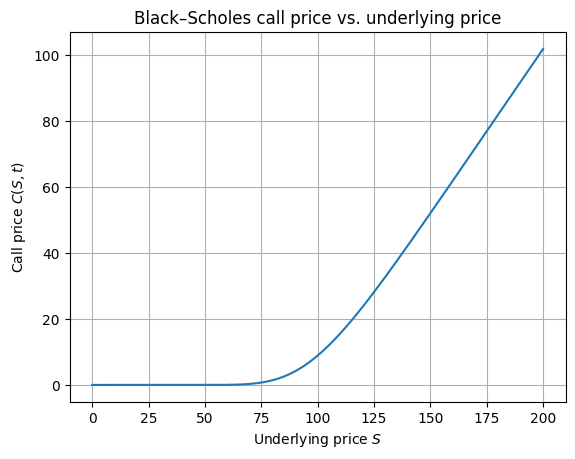

In [100]:
# Call price as a function of underlying price S (smooth for t < T)
r, T, t, sigma, K = 0.02, 1.0, 0.0, 0.2, 100
S = np.linspace(0, 200, 1000)

plt.plot(S, bs_price_call(S, K, T, t, r, sigma))
plt.xlabel("Underlying price $S$")
plt.ylabel("Call price $C(S,t)$")
plt.title("Black–Scholes call price vs. underlying price")
plt.grid(True)


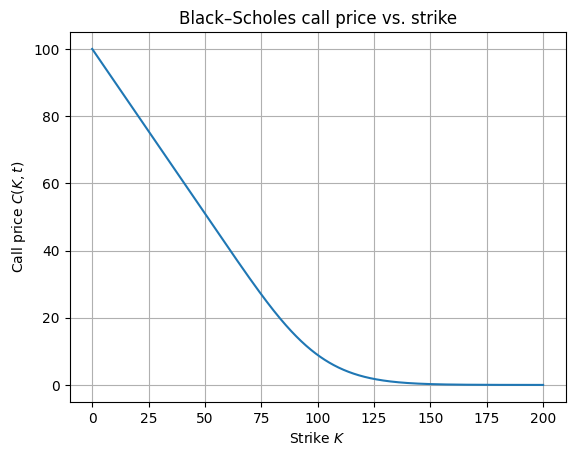

In [101]:
# Call price with respect to strikes K (smooth if t < T)
r, T, t, sigma = 0.02, 1.0, 0.0, 0.2
S = 100.0
K = np.linspace(1e-6, 200, 1000)

plt.plot(K, bs_price_call(S, K, T, t, r, sigma))
plt.xlabel("Strike $K$")
plt.ylabel("Call price $C(K,t)$")
plt.title("Black–Scholes call price vs. strike")
plt.grid(True)


##### Defining class Heston-IV-ANN

In [5]:
class Heston_ANN(nn.Module):
  def __init__(self):
    """
    Initilize Heston-IV-ANN netwwork with four hidden layers. 
    Same architecture as the one used in Table (2) [2].
    Weight are initialized using Glorot_uniform also known as Xavier_uniform.
    """
    super(Heston_ANN, self).__init__()
    # 4 layers
    self.fc1 = nn.Linear(8, 200)
    self.fc2 = nn.Linear(200, 200)
    self.fc3 = nn.Linear(200, 200)
    self.fc4 = nn.Linear(200, 200)
    self.fc5 = nn.Linear(200, 1)
    # initilizing the layer's weights
    torch.nn.init.xavier_uniform_(self.fc1.weight) 
    torch.nn.init.xavier_uniform_(self.fc2.weight)
    torch.nn.init.xavier_uniform_(self.fc3.weight)
    torch.nn.init.xavier_uniform_(self.fc4.weight)
    torch.nn.init.xavier_uniform_(self.fc5.weight)


  def forward(self, x):
    """
    Foward pass of the network. 
    Relu activations are used and a linear activation is used in the final layer.
    x: input torch tensor (CUDA or CPU)
    """
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = F.relu(self.fc4(x))
    x = self.fc5(x)
    return x.flatten()

  def train_model(self, args, device, train_loader, optimizer, epoch):
    """
    Training over train_loader batches for one epoch.
    Returns average training loss.
    args: training parameters.
    device: CUDA or CPU.
    train_loader: train data loader.
    optimizer: gradient descent optmizer.
    epoch: current epoch.
    """
    # train mode
    self.train()
    train_loss = 0
    # loop over data loader
    for batch_idx, data in enumerate(train_loader):
      # extracting the inputs and target
      data, target = data[:,:-1].to(device), data[:,-1].to(device)
      # zeroing the gradients
      optimizer.zero_grad()
      # foward pass
      output = self(data)
      # computing the loss
      loss = F.mse_loss(output, target)
      train_loss += loss.item() * data.shape[0]
      # back propagation
      loss.backward()
      # updating the optimizer step
      optimizer.step()
      # printing batch information
      if batch_idx % args["log_interval"] == 0:
        print('Train Epoch: {} [{}/{} ({:.0f}%)]\tlog Loss: {:.6f}'.format(
            epoch, int(batch_idx / len(train_loader)*len(train_loader.dataset)), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), np.log(loss.item())))
        if args["dry_run"]:
          break
    train_loss /= len(train_loader.dataset)
    print('\nTrain set: Average log loss: {:.4f}\n'.format(np.log(train_loss))) 
    return train_loss


  def test_model(self, device, test_loader):
    """
    Testing over test_loader batches for one epoch. 
    Returns average test loss.
    device: CUDA or CPU.
    test_loader: test data loader.
    """
    # evaluation mode
    self.eval()
    test_loss = 0
    # freezing the gradients
    with torch.no_grad():
      # looping over the test laoder
      for data in test_loader:
        # extracting the inputs and target
        data, target = data[:,:-1].to(device), data[:,-1].to(device)
        # foward pass
        output = self(data)
        #computing the loss
        test_loss += F.mse_loss(output, target, reduction = 'sum').item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}\n'.format(np.log(test_loss))) 
    return test_loss

In [55]:
class SABR_ANN(nn.Module):
  def __init__(self):
    """
    Initilize Heston-IV-ANN netwwork with four hidden layers. 
    Same architecture as the one used in Table (2) [2].
    Weight are initialized using Glorot_uniform also known as Xavier_uniform.
    """
    super(SABR_ANN, self).__init__()
    # 4 layers
    self.fc1 = nn.Linear(7, 200)
    self.fc2 = nn.Linear(200, 200)
    self.fc3 = nn.Linear(200, 200)
    self.fc4 = nn.Linear(200, 200)
    self.fc5 = nn.Linear(200, 1)
    # initilizing the layer's weights
    torch.nn.init.xavier_uniform_(self.fc1.weight) 
    torch.nn.init.xavier_uniform_(self.fc2.weight)
    torch.nn.init.xavier_uniform_(self.fc3.weight)
    torch.nn.init.xavier_uniform_(self.fc4.weight)
    torch.nn.init.xavier_uniform_(self.fc5.weight)


  def forward(self, x):
    """
    Foward pass of the network. 
    Relu activations are used and a linear activation is used in the final layer.
    x: input torch tensor (CUDA or CPU)
    """
    x = Fnn.relu(self.fc1(x))
    x = Fnn.relu(self.fc2(x))
    x = Fnn.relu(self.fc3(x))
    x = Fnn.relu(self.fc4(x))
    x = self.fc5(x)
    return x.flatten()

  def train_model(self, args, device, train_loader, optimizer, epoch):
    """
    Training over train_loader batches for one epoch.
    Returns average training loss.
    args: training parameters.
    device: CUDA or CPU.
    train_loader: train data loader.
    optimizer: gradient descent optmizer.
    epoch: current epoch.
    """
    # train mode
    self.train()
    train_loss = 0
    # loop over data loader
    for batch_idx, data in enumerate(train_loader):
      # extracting the inputs and target
      data, target = data[:,:-1].to(device), data[:,-1].to(device)
      # zeroing the gradients
      optimizer.zero_grad()
      # foward pass
      output = self(data)
      # computing the loss
      loss = Fnn.mse_loss(output, target)
      train_loss += loss.item() * data.shape[0]
      # back propagation
      loss.backward()
      # updating the optimizer step
      optimizer.step()
      # printing batch information
      if batch_idx % args["log_interval"] == 0:
        print('Train Epoch: {} [{}/{} ({:.0f}%)]\tlog Loss: {:.6f}'.format(
            epoch, int(batch_idx / len(train_loader)*len(train_loader.dataset)), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), np.log(loss.item())))
        if args["dry_run"]:
          break
    train_loss /= len(train_loader.dataset)
    print('\nTrain set: Average log loss: {:.4f}\n'.format(np.log(train_loss))) 
    return train_loss


  def test_model(self, device, test_loader):
    """
    Testing over test_loader batches for one epoch. 
    Returns average test loss.
    device: CUDA or CPU.
    test_loader: test data loader.
    """
    # evaluation mode
    self.eval()
    test_loss = 0
    # freezing the gradients
    with torch.no_grad():
      # looping over the test laoder
      for data in test_loader:
        # extracting the inputs and target
        data, target = data[:,:-1].to(device), data[:,-1].to(device)
        # foward pass
        output = self(data)
        #computing the loss
        test_loss += Fnn.mse_loss(output, target, reduction = 'sum').item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}\n'.format(np.log(test_loss))) 
    return test_loss

## b) Data generation

### Numerical method here: Heston and COS

#### COS Method

#### Vanilla call coefficients

$\begin{aligned} \chi_{k}(c, d):=& \frac{1}{1+\left(\frac{k \pi}{b-a}\right)^{2}}\left[\cos \left(k \pi \frac{d-a}{b-a}\right) e^{d}-\cos \left(k \pi \frac{c-a}{b-a}\right) e^{c}\right.\\ &\left.+\frac{k \pi}{b-a} \sin \left(k \pi \frac{d-a}{b-a}\right) e^{d}-\frac{k \pi}{b-a} \sin \left(k \pi \frac{c-a}{b-a}\right) e^{c}\right] \end{aligned}$

$\psi_{k}(c, d):= \begin{cases}{\left[\sin \left(k \pi \frac{d-a}{b-a}\right)-\sin \left(k \pi \frac{c-a}{b-a}\right)\right] \frac{b-a}{k \pi},} & k \neq 0, \\ (d-c), & k=0 .\end{cases}$

$V_{k}^{\text {call }}=\frac{2}{b-a} K\left(\chi_{k}(0, b)-\psi_{k}(0, b)\right)$

In [6]:
def call_cosine_coef(a, b, c, d, K, N):
  """
  Coefficient V_k for plain vanilla options. 
  Section 3.1, equations (22) and (23).
  a, b, c, d: truncation range parameters.
  K: Strike.
  N: summing lenght.
  Returns V_k coefficient for call option.
  """
  k = np.arange(N).reshape(1,-1)
  bma    = b - a
  uu     = k * np.pi / bma
  chi_k = 1 / (1 + uu **2 ) * \
  ( np.cos(uu * ( d - a))* np.exp(d) - np.cos(uu * (c - a))* np.exp(c) + uu * np.sin(uu * (d - a)) * np.exp(d)- uu * np.sin(uu*(c-a))* np.exp(c) )
  psi_k = uu
  psi_k[:,1:] = 1 / uu[:,1:] * ( np.sin(uu[:,1:] * ( d - a )) - np.sin( uu[:,1:] * ( c - a) ) )
  psi_k[:,0] = (d - c).flatten() #d - c 
  return 2/bma*K*(chi_k-psi_k)

In [7]:
def call_cosine_coef_moy(a, b, c, d, N):
  """
  Moyeness version.
  Coefficient V_k for plain vanilla options. 
  Section 3.1, equations (22) and (23).
  a, b, c, d: truncation range parameters.
  N: summing lenght.
  Returns V_k coefficient for call option devided by K.
  """
  k = np.arange(N).reshape(1,-1)
  bma    = b - a
  uu     = k * np.pi / bma
  chi_k = 1 / (1 + uu **2 ) * \
  ( np.cos(uu * ( d - a))* np.exp(d) - np.cos(uu * (c - a))* np.exp(c) + uu * np.sin(uu * (d - a)) * np.exp(d)- uu * np.sin(uu*(c-a))* np.exp(c) )
  psi_k = uu
  psi_k[:,1:] = 1 / uu[:,1:] * ( np.sin(uu[:,1:] * ( d - a )) - np.sin( uu[:,1:] * ( c - a) ) )
  psi_k[:,0] = (d - c).flatten() #d - c 
  return 2/bma*(chi_k-psi_k)

#### Charateristic function for Heston model

$\begin{aligned} \varphi_{h e s}\left(\omega ; u_{0}\right)=& \exp \left(i \omega \mu \Delta t+\frac{u_{0}}{\eta^{2}}\left(\frac{1-e^{-D \Delta t}}{1-G e^{-D \Delta t}}\right)(\lambda-i \rho \eta \omega-D)\right) \\ & \cdot \exp \left(\frac{\lambda \bar{u}}{\eta^{2}}\left(\Delta t(\lambda-i \rho \eta \omega-D)-2 \log \left(\frac{1-G e^{-D \Delta t}}{1-G}\right)\right)\right) \end{aligned}$

$D=\sqrt{(\lambda-i \rho \eta \omega)^{2}+\left(\omega^{2}+i \omega\right) \eta^{2}} \quad$ and $\quad G=\frac{\lambda-i \rho \eta \omega-D}{\lambda-i \rho \eta \omega+D} $

In [8]:
def phi_Heston(a ,b ,N ,r, tau, kappa, gamma, vbar, v0, rho):
  """
  Characteristic function of the log-asset price following the Heston model.
  Section 3.3, equation (33).
  a, b: truncation range parameters.
  N: summing lenght.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  Returns Charateristic function vector.
  """
  #if kappa < 1e-4:
  #  print("kapp < 1e-4")
  #  kappa = 1e-5
  k = np.arange(N).reshape(1,-1)
  u = np.pi*k/(b-a)
  i = complex(0.0,1.0)
  D = np.sqrt((kappa-gamma*rho*i*u)**2+(u**2+i*u)*gamma**2)
  G = (kappa-gamma*rho*i*u-D)/(kappa-gamma*rho*i*u+D)
  C = v0* (1-np.exp(-D*tau)) / (gamma**2*(1-G*np.exp(-D*tau)))*(kappa-gamma*rho*i*u-D)
  A = r*i*u*tau + kappa*vbar/(gamma**2)*(tau*(kappa-gamma*rho*i*u-D) -2*np.log( (1-G*np.exp(-D*tau))/(1-G) )   ) 
  phi = np.exp( A + C )
  return phi


#### Heston cumulants

$c_{1}=\mu T+\left(1-e^{-\lambda T}\right) \frac{\bar{u}-u_{0}}{2 \lambda}-\frac{1}{2} \bar{u} T$

$\begin{aligned} c_{2}=& \frac{1}{8 \lambda^{3}}\left(\eta T \lambda e^{-\lambda T}\left(u_{0}-\bar{u}\right)(8 \lambda \rho-4 \eta)\right.\\ &+\lambda \rho \eta\left(1-e^{-\lambda T}\right)\left(16 \bar{u}-8 u_{0}\right) \\ &+2 \bar{u} \lambda T\left(-4 \lambda \rho \eta+\eta^{2}+4 \lambda^{2}\right) \\ &+\eta^{2}\left(\left(\bar{u}-2 u_{0}\right) e^{-2 \lambda T}+\bar{u}\left(6 e^{-\lambda T}-7\right)+2 u_{0}\right) \\ &\left.+8 \lambda^{2}\left(u_{0}-\bar{u}\right)\left(1-e^{-\lambda T}\right)\right) \end{aligned}$

In [9]:
def Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho ):
  """
  Computes Heston cumulants as defined in the appendix A for the Heston model.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  Returns cumulants c1 and c2.
  """

  #if kappa == 0:
  #  c1 = r * tau + tau * (vbar - v0) / 2 - 0.5 * vbar * tau
  #else: 
  #   c1 = r * tau + (1 - np.exp(- kappa * tau)) * (vbar - v0) / (2 * kappa) - 0.5 * vbar * tau
  
  c1 = r * tau + (1 - np.exp(- kappa * tau)) * (vbar - v0) / (2 * kappa) - 0.5 * vbar * tau


  #safe_kappa = np.max(kappa, 1e-5)
  safe_kappa = kappa
  c2 = 0.125 / safe_kappa ** 3 * (gamma * tau * np.exp(- safe_kappa * tau) * (v0 - vbar) * (8 * safe_kappa * rho - 4 * gamma) + \
     safe_kappa * rho * gamma * (1 - np.exp(- safe_kappa * tau)) * (16 * vbar - 8 * v0) + \
     2 * vbar * safe_kappa * tau * (- 4 * safe_kappa * rho * gamma + gamma ** 2 + 4 * safe_kappa ** 2) + \
     gamma ** 2 * ((vbar - 2 * v0) * np.exp(-2 * safe_kappa * tau) + vbar * (6 * np.exp(- safe_kappa * tau) - 7) + 2 * v0) + \
     8 * safe_kappa ** 2 * (v0 - vbar) * (1 - np.exp(-safe_kappa * tau)))
  return c1, c2

#### Truncation range

$[a, b]:=\left[c_{1}-L \sqrt{c_{2}+\sqrt{c_{4}}}, \quad c_{1}+L \sqrt{c_{2}+\sqrt{c_{4}}}\right]$

In [10]:
def Truncation_range(c1, c2, c4, L):
  """
  Computes the truncation range given the cumulants c1, c2, c4 and the truncation lenght L.
  c1, c2, c4: Model cumulants.
  L: truncation lenght.
  Returns tuncation interval sup b and inf a.
  """
  a = c1 - L * np.sqrt( np.abs( c2 ) + np.sqrt( np.abs(c4) ) )
  b = c1 + L * np.sqrt( np.abs( c2 ) + np.sqrt( np.abs(c4) ) ) 
  return a, b

#### Exponential coefficient

$e^{i k \pi \frac{\mathbf{x}-a}{b-a}}$

In [11]:
def exponential_coef(a, b, N, S0, K):
  """
  Computes the exponential coefficient used in the final pricing sum.
  a, b: truncation range.
  N: sum lenght.
  S0: asset initial price.
  K: strike.
  Returns the exponential coefficient vector.
  """
  i = complex(0.0,1.0)
  k = np.arange(N).reshape(1,-1)
  return np.exp(i*k*np.pi*(np.log(S0/K)-a)/(b-a))

In [12]:
def exponential_coef_moy(a, b, N, moyeness):
  """
  Moyeness version.
  Computes the exponential coefficient used in the final pricing sum.
  a, b: truncation range.
  N: sum lenght.
  moyeness: S/K.
  Returns the exponential coefficient vector devided by K.
  """
  i = complex(0.0,1.0)
  k = np.arange(N).reshape(1,-1)
  return np.exp(i*k*np.pi*(np.log(moyeness)-a)/(b-a))

#### Vanilla call price

$v\left(\mathbf{x}, t_{0}, u_{0}\right) \approx \mathbf{K} e^{-r \Delta t} \cdot \operatorname{Re}\left\{\sum_{k=0}^{N-1} \varphi_{h e s}\left(\frac{k \pi}{b-a} ; u_{0}\right) U_{k} \cdot e^{i k \pi \frac{\mathbf{x}-a}{b-a}}\right\}$

In [13]:
def call_option_Heston(N, L, r, tau, kappa, gamma, vbar, v0, rho, K, S0 ):
  """
  Computes call option price using COS method.
  N: sum lenght.
  L: truncation lenght.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  S0: asset initial price.
  K: strike.
  Returns option price.
  """
  c1, c2 = Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho )
  c4 = 0
  a, b = Truncation_range(c1, c2, c4, L)
  c= 0
  d = b
  V_k = call_cosine_coef(a, b, c, d, K, N)
  phi_k = phi_Heston(a, b, N, r, tau, kappa, gamma, vbar, v0, rho)
  product_k = V_k * phi_k * exponential_coef(a, b, N, S0, K)
  product_k[:,0] = .5 * product_k[:,0]
  return np.exp(-r*tau)*(np.real(  np.sum( product_k,1 )  )).reshape(-1,1)

In [14]:
# cheking the function
N = 500
L= 12
r= .1
tau= 1.4
rho = -0.95
kappa= 1.4
vbar = .1
gamma = .1
v0 = 0.5
K = 100
S0 = 100
# Feller's condition
print(2*kappa*vbar>gamma**2)
call_option_Heston(N = 1500, L= 12, r= r, tau= tau, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, K = K, S0 = S0)

True


array([[29.79261082]])

In [15]:
def call_option_Heston_moy(N, L, r, tau, kappa, gamma, vbar, v0, rho, moyeness ):
  """
  Moyeness version.
  Computes call option price using COS method.
  N: sum lenght.
  L: truncation lenght.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  moyeness: S/K.
  Returns option price.
  """
  c1, c2 = Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho )
  c4 = 0
  a, b = Truncation_range(c1, c2, c4, L)
  c= 0
  d = b
  V_k = call_cosine_coef_moy(a, b, c, d, N)
  phi_k = phi_Heston(a, b, N, r, tau, kappa, gamma, vbar, v0, rho)
  product_k = V_k * phi_k * exponential_coef_moy(a, b, N, moyeness)
  product_k[:,0] = .5 * product_k[:,0]
  return np.exp(-r*tau)*(np.real(  np.sum( product_k,1 )  )).reshape(-1,1)

In [16]:
# cheking the function
N = 500
L= 12
r= .1
tau= 1.4
rho = -0.95
kappa= 1.4
vbar = .1
gamma = .1
v0 = 0.5
K = 100
S0 = 100
# Feller's condition
print(2*kappa*vbar>gamma**2)
call_option_Heston_moy(N = 1500, L= 12, r= r, tau= tau, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, moyeness = 1)

True


array([[0.29792611]])

# Latin Hypercube Sampling

### Generating Data

#### Sampling range for the Heston parameters (Table (3) in [1])

In [ ]:
# here Table (3) of [1] is used, kappa is numerically sensitive to small values
eps = 1e-2 # is used to generate open intervals
# [m,       tau,        r,        rho,    kappa,     rho,       nu]
def Heston_LHS_data_generator(n = 10**6, l_bounds = [.6+eps, .05+eps, .0+eps, -0.9+eps, 0.4+eps, .01+eps, .01+eps, .05+eps], u_bounds = [1.4-eps, 3.0-eps, .05-eps, 0.0-eps, 3.0-eps, .5-eps, .8-eps, .5-eps]):
  """
  Generates samples of call prices using Latin hypercube sampling.
  Returns a torch float tensor of dimension (n,9) containig the inputs samples and the value of the call.
  The inputs are: Moyeness (S/K), time to maturity (tau), Risk free rate (r), Correlation (rho), reversion speed (kappa), Long average variance (vbar), Vol of vol (gamma), Initial variance (v0).
  n: number of samples.
  l_bounds: lower bound for the inputs.  
  u_bounds: upper bound for the inputs.
  """
  sampler = qmc.LatinHypercube(d = 8) #, seed = 0
  sample = sampler.random(n)
  sample = qmc.scale(sample, l_bounds, u_bounds)
  indecies = np.argwhere(2*sample[:,4]*sample[:,5] <= sample[:,6]**2)
  sample = np.delete(sample, indecies, 0)
  hs_prices = call_option_Heston_moy(N = 500, L= 12, r= sample[:,2].reshape((-1,1)), tau= sample[:,1].reshape((-1,1)), kappa = sample[:,4].reshape((-1,1)),\
                                     gamma = sample[:,6].reshape((-1,1)), vbar = sample[:,5].reshape((-1,1)), v0 = sample[:,7].reshape((-1,1)),\
                                     rho = sample[:,3].reshape((-1,1)), moyeness = sample[:,0].reshape((-1,1))).reshape((-1,1))
  #hs_prices = call_option_Heston_moy(N = 1500, L= 50, r= sample[:,2].reshape((-1,1)), tau= sample[:,1].reshape((-1,1)), kappa= sample[:,4].reshape((-1,1)),\
  #                                    gamma = sample[:,6].reshape((-1,1)), vbar = sample[:,5].reshape((-1,1)), v0 = sample[:,7].reshape((-1,1)),\
  #                                    rho = sample[:,3].reshape((-1,1)), moyeness = sample[:,0].reshape((-1,1))).reshape((-1,1))

  # hs_dataset = np.concatenate((sample, hs_prices),axis=1)

  print("------ INPUT ------")
  print("S/K.......... [{:.2f}, {:.2f}]".format(sample[:,0].min(), sample[:,0].max()))
  print("Tau.......... [{:.2f}, {:.2f}]".format(sample[:,1].min(), sample[:,1].max()))
  print("r............ [{:.2f}, {:.2f}]".format(sample[:,2].min(), sample[:,2].max()))
  print("Corr ........ [{:.2f}, {:.2f}]".format(sample[:,3].min(), sample[:,3].max()))
  print("Kappa........ [{:.2f}, {:.2f}]".format(sample[:,4].min(), sample[:,4].max()))
  print("V_bar........ [{:.2f}, {:.2f}]".format(sample[:,5].min(), sample[:,5].max()))
  print("Gamma........ [{:.2f}, {:.2f}]".format(sample[:,6].min(), sample[:,6].max()))
  print("V_0 ......... [{:.2f}, {:.2f}]".format(sample[:,7].min(), sample[:,7].max()))
  print("------ OUTPUT ------")
  print("V/K.......... [{:.2f}, {:.2f}]".format(hs_prices.min(), hs_prices.max()))

  return sample, hs_prices

In [103]:
eps = 1e-12 

def SABR_LHS_data_generator_pysabr_moneyness(
    n=10**6,
    seed=0,
    # sample columns: [m, T, F, alpha, beta, rho, nu]
    # m = K/F  ->  K = m*F
    l_bounds=(0.8+eps, 0.25+eps, 0.001+eps, 0.001+eps, 0.30+eps, -0.90+eps, 0.05+eps),
    u_bounds=(1.2-eps, 10.0-eps, 0.060-eps, 0.100-eps, 1.00-eps,  0.90-eps, 0.80-eps),
    vol_cap=5.0,
):
    """
    Generate SABR NORMAL (Bachelier) implied vols using LHS and pysabr.normal_vol.

    Inputs per row (all as column vectors after reshape):
      m      : moneyness (K/F), so K = m*F
      T      : expiry
      F      : forward
      alpha  : SABR alpha parameter (NOT v_atm_n)
      beta   : SABR beta
      rho    : correlation
      nu     : vol-of-vol (volvol)

    Returns:
      sample_valid : (N, 7) array  [m, T, F, alpha, beta, rho, nu]
      vols_valid   : (N, 1) array  normal implied vols
    """
    l_bounds = np.array(l_bounds, dtype=float)
    u_bounds = np.array(u_bounds, dtype=float)

    sampler = qmc.LatinHypercube(d=7, seed=seed)
    sample = qmc.scale(sampler.random(n), l_bounds, u_bounds)

    m     = sample[:, 0].reshape(-1, 1)
    T     = sample[:, 1].reshape(-1, 1)
    fwd     = sample[:, 2].reshape(-1, 1)
    alpha = sample[:, 3].reshape(-1, 1)
    beta  = sample[:, 4].reshape(-1, 1)
    rho   = sample[:, 5].reshape(-1, 1)
    nu    = sample[:, 6].reshape(-1, 1)

    # Ensure strictly positive forwards
    fwd = np.maximum(fwd, eps)

    # Build strikes (positive if m>0 and F>0)
    K = m * fwd

    # Domain filter (boolean mask shape (n,))
    base_valid = (
        (T[:, 0] > eps) &
        (fwd[:, 0] > eps) &
        (K[:, 0] > eps) &
        (alpha[:, 0] > 0.0) &
        (nu[:, 0] >= 0.0) &
        (beta[:, 0] >= 0.0) & (beta[:, 0] <= 1.0) &
        (np.abs(rho[:, 0]) < 1.0)
    )

    sample = sample[base_valid]
    m     = m[base_valid]
    T     = T[base_valid]
    fwd   = fwd[base_valid]
    K     = K[base_valid]
    alpha = alpha[base_valid]
    beta  = beta[base_valid]
    rho   = rho[base_valid]
    nu    = nu[base_valid]

    # Evaluate vols
    vols = np.empty((sample.shape[0], 1), dtype=float)
    for i in range(sample.shape[0]):
        vols[i, 0] = hagan_normal.normal_vol(
            k=float(K[i, 0]),
            f=float(fwd[i, 0]),
            t=float(T[i, 0]),
            alpha=float(alpha[i, 0]),
            beta=float(beta[i, 0]),
            rho=float(rho[i, 0]),
            volvol=float(nu[i, 0]),
        )

    # Clean output
    v = vols[:, 0]
    valid = np.isfinite(v) & (v > 0.0) & (v < vol_cap)
    sample_valid = sample[valid]
    vols_valid = vols[valid].reshape(-1, 1)

    if len(vols_valid) > 0:
        print("------ INPUT (SABR) ------")
        print("m (K/F)...... [{:.3f}, {:.3f}]".format(sample_valid[:,0].min(), sample_valid[:,0].max()))
        print("K............ [{:.6f}, {:.6f}]".format(K.min(), K.max()))
        print("T............ [{:.3f}, {:.3f}]".format(sample_valid[:,1].min(), sample_valid[:,1].max()))
        print("F............ [{:.6f}, {:.6f}]".format(sample_valid[:,2].min(), sample_valid[:,2].max()))
        print("alpha........ [{:.6f}, {:.6f}]".format(sample_valid[:,3].min(), sample_valid[:,3].max()))
        print("beta......... [{:.3f}, {:.3f}]".format(sample_valid[:,4].min(), sample_valid[:,4].max()))
        print("rho.......... [{:.3f}, {:.3f}]".format(sample_valid[:,5].min(), sample_valid[:,5].max()))
        print("nu........... [{:.3f}, {:.3f}]".format(sample_valid[:,6].min(), sample_valid[:,6].max()))
        print("------ OUTPUT ------")
        print("normal vol... [{:.6f}, {:.6f}]".format(vols_valid.min(), vols_valid.max()))
        print(f"Kept {len(vols_valid)} / {n} rows after filtering")

    return sample_valid, vols_valid




In [ ]:
sample_sabr, sabr_vols = SABR_LHS_data_generator_pysabr_moneyness(n=10**5, seed=42)

final_dataset_sabr = np.concatenate([sample_sabr, sabr_vols], axis=1)   # sabr_vols is already (N,1)
sabr_dataset = torch.FloatTensor(final_dataset_sabr)


------ INPUT (SABR) ------
m (K/F)...... [0.800, 1.200]
K............ [0.000811, 0.071832]
T............ [0.250, 10.000]
F............ [0.001001, 0.060000]
alpha........ [0.001001, 0.099999]
beta......... [0.300, 1.000]
rho.......... [-0.900, 0.900]
nu........... [0.050, 0.800]
------ OUTPUT ------
normal vol... [0.000004, 0.059454]
Kept 99535 / 100000 rows after filtering


In [10]:
eps = 1e-2  # open intervals

def SABR_LHS_data_generator(
    n = 10**6,
    # [x,       T,        F,        alpha,    beta,     rho,       nu]
    l_bounds = [-0.02+eps, 0.25+eps, 0.00+eps, 0.005+eps, 0.30+eps, -0.90+eps, 0.05+eps],
    u_bounds = [ 0.02-eps,10.00-eps, 0.06-eps, 0.100-eps, 1.00-eps,  0.90-eps, 0.80-eps]
):
    """
    Generate SABR normal implied vols using Latin hypercube sampling.

    Inputs:
      x      : strike offset relative to forward (e.g. K = F + x)
      T      : option expiry in years
      F      : forward swap rate
      alpha  : SABR alpha (vol level)
      beta   : SABR beta (elasticity)
      rho    : SABR correlation
      nu     : SABR vol-of-vol

    Returns:
      sample : array of shape (N, 7) with inputs
      vols   : array of shape (N, 1) with normal implied vols
    """
    sampler = qmc.LatinHypercube(d = 7)
    sample = sampler.random(n)
    sample = qmc.scale(sample, l_bounds, u_bounds)

    x     = sample[:,0].reshape(-1,1)
    T     = sample[:,1].reshape(-1,1)
    F     = sample[:,2].reshape(-1,1)
    alpha = sample[:,3].reshape(-1,1)
    beta  = sample[:,4].reshape(-1,1)
    rho   = sample[:,5].reshape(-1,1)
    nu    = sample[:,6].reshape(-1,1)

    # Build strikes
    K = F + x

    # Basic domain filter (important when beta is fractional)
    base_valid = (T > eps) & (F > eps) & (K > eps) & (alpha > 0) & (nu >= 0) & (beta >= 0) & (beta <= 1) & (np.abs(rho) < 1)
    sample = sample[base_valid]
    x, T, F, K, alpha, beta, rho, nu = x[base_valid], T[base_valid], F[base_valid], K[base_valid], alpha[base_valid], beta[base_valid], rho[base_valid], nu[base_valid]

    # Evaluate vols (loop; pysabr functions are scalar)
    vols = np.empty(sample.shape[0], dtype=float)
    for i in range(sample.shape[0]):
        vols[i] = sabr.normal_vol(F[i], K[i], T[i], alpha[i], beta[i], rho[i], nu[i])

    # Clean output
    valid = np.isfinite(vols) & (vols > 0.0) & (vols < 5.0)
    sample_valid = sample[valid]
    vols_valid = vols[valid].reshape(-1, 1)

    if sample_valid.shape[0] > 0:
        print("------ INPUT (SABR, pysabr) ------")
        print("x (K-F)...... [{:.4f}, {:.4f}]".format(sample_valid[:,0].min(), sample_valid[:,0].max()))
        print("T............ [{:.2f}, {:.2f}]".format(sample_valid[:,1].min(), sample_valid[:,1].max()))
        print("F............ [{:.4f}, {:.4f}]".format(sample_valid[:,2].min(), sample_valid[:,2].max()))
        print("alpha........ [{:.4f}, {:.4f}]".format(sample_valid[:,3].min(), sample_valid[:,3].max()))
        print("beta......... [{:.2f}, {:.2f}]".format(sample_valid[:,4].min(), sample_valid[:,4].max()))
        print("rho.......... [{:.2f}, {:.2f}]".format(sample_valid[:,5].min(), sample_valid[:,5].max()))
        print("nu........... [{:.4f}, {:.4f}]".format(sample_valid[:,6].min(), sample_valid[:,6].max()))
        print("------ OUTPUT ------")
        print("normal vol... [{:.6f}, {:.6f}]".format(vols_valid.min(), vols_valid.max()))
        print(f"Kept {len(vols_valid)} / {n} rows after filtering")

    return sample_valid, vols_valid



In [11]:
sample_sabr, sabr_vols = SABR_LHS_data_generator(n=5000)

# 1) basic sanity
print("\nSanity:")
print("Shapes:", sample_sabr.shape, sabr_vols.shape)
print("All finite:", np.isfinite(sabr_vols).all())
print("All positive:", (sabr_vols > 0).all())

# 2) recompute one row and compare (should be identical up to float error)
i = min(123, len(sample_sabr) - 1)
x, T, F, alpha, beta, rho, nu = sample_sabr[i]
K = F + x
v_check = sabr.normal_vol(F, K, T, alpha, beta, rho, nu)
diff = abs(float(sabr_vols[i,0]) - float(v_check))
print("Recompute diff:", diff)

IndexError: boolean index did not match indexed array along dimension 1; dimension is 7 but corresponding boolean dimension is 1

In [7]:
eps = 1e-2  # open intervals

def SABR_LHS_data_generator(
    n = 10**6,
    # [x,       T,        F,        alpha,    beta,     rho,       nu]
    l_bounds = [-0.02+eps, 0.25+eps, 0.00+eps, 0.005+eps, 0.30+eps, -0.90+eps, 0.05+eps],
    u_bounds = [ 0.02-eps,10.00-eps, 0.06-eps, 0.100-eps, 1.00-eps,  0.90-eps, 0.80-eps]
):
    """
    Generate SABR normal implied vols using Latin hypercube sampling.

    Inputs:
      x      : strike offset relative to forward (e.g. K = F + x)
      T      : option expiry in years
      F      : forward swap rate
      alpha  : SABR alpha (vol level)
      beta   : SABR beta (elasticity)
      rho    : SABR correlation
      nu     : SABR vol-of-vol

    Returns:
      sample : array of shape (N, 7) with inputs
      vols   : array of shape (N, 1) with normal implied vols
    """
    sampler = qmc.LatinHypercube(d = 7)
    sample = sampler.random(n)
    sample = qmc.scale(sample, l_bounds, u_bounds)

    x     = sample[:,0].reshape(-1,1)
    T     = sample[:,1].reshape(-1,1)
    F     = sample[:,2].reshape(-1,1)
    alpha = sample[:,3].reshape(-1,1)
    beta  = sample[:,4].reshape(-1,1)
    rho   = sample[:,5].reshape(-1,1)
    nu    = sample[:,6].reshape(-1,1)

    # strike = forward + offset (can also use K = F * exp(x) etc.)
    K = F + x

    vols = []
    for i in range(sample.shape[0]):
        sabr = Hagan2002NormalSABR(
            f     = float(F[i]),
            shift = 0.0,
            t     = float(T[i]),
            v_atm_n = float(alpha[i]),   # or map alpha differently if needed
            beta  = float(beta[i]),
            rho   = float(rho[i]),
            volvol = float(nu[i]),
        )
        vol_i = sabr.normal_vol(float(K[i]))
        vols.append(vol_i)

    vols = np.array(vols).reshape(-1,1)

    print("------ INPUT (SABR) ------")
    print("x (K-F)...... [{:.4f}, {:.4f}]".format(x.min(), x.max()))
    print("T............ [{:.2f}, {:.2f}]".format(T.min(), T.max()))
    print("F............ [{:.4f}, {:.4f}]".format(F.min(), F.max()))
    print("alpha........ [{:.4f}, {:.4f}]".format(alpha.min(), alpha.max()))
    print("beta......... [{:.2f}, {:.2f}]".format(beta.min(), beta.max()))
    print("rho.......... [{:.2f}, {:.2f}]".format(rho.min(), rho.max()))
    print("nu........... [{:.4f}, {:.4f}]".format(nu.min(), nu.max()))
    print("------ OUTPUT ------")
    print("normal vol... [{:.2f}, {:.2f}] (abs level)".format(vols.min(), vols.max()))

    return sample, vols


In [8]:
SABR_LHS_data_generator()

------ INPUT (SABR) ------
x (K-F)...... [-0.0100, 0.0100]
T............ [0.26, 9.99]
F............ [0.0100, 0.0500]
alpha........ [0.0150, 0.0900]
beta......... [0.31, 0.99]
rho.......... [-0.89, 0.89]
nu........... [0.0600, 0.7900]
------ OUTPUT ------
normal vol... [-0.02, 2.20] (abs level)


(array([[-5.13681170e-03,  4.47926431e+00,  3.10334547e-02, ...,
          7.53911493e-01,  3.53816450e-03,  7.83338144e-01],
        [ 1.59515124e-03,  8.67196861e+00,  1.46638329e-02, ...,
          6.42280353e-01, -6.16006666e-01,  1.73189810e-01],
        [-9.83816114e-03,  4.24874735e+00,  4.42573324e-02, ...,
          4.23017880e-01, -6.64557632e-01,  3.41660942e-01],
        ...,
        [-3.95753336e-03,  7.74956314e-01,  4.28040401e-02, ...,
          9.89110456e-01, -6.24039592e-01,  6.65577276e-01],
        [ 8.41142606e-03,  3.76048466e+00,  1.41625156e-02, ...,
          4.51110037e-01,  8.51931463e-01,  7.70456404e-01],
        [-3.01337863e-03,  9.77472692e+00,  1.36166130e-02, ...,
          5.92952241e-01,  1.17482069e-01,  2.73189805e-01]]),
 array([[0.01923864],
        [0.06716478],
        [0.07387405],
        ...,
        [0.05575692],
        [0.04951534],
        [0.04401645]]))

In [39]:
sample_sabr, sabr_vols = SABR_LHS_data_generator(n=10**5)

print("------ ANN OUTPUT (SABR) ------")
print("Normal IV sigma.......... [{:.2f}, {:.2f}]".format(sabr_vols.min(), sabr_vols.max()))

# Filter out junk vols (negative, NaN, absurdly large)
v = sabr_vols.squeeze()
valid_idx = (~np.isnan(v)) & (v > 0.0) & (v < 5.0)  # adjust upper bound if you like

sample_sabr = sample_sabr[valid_idx]
sabr_vols   = sabr_vols[valid_idx]

# Combine inputs + target IV into one array
final_dataset_sabr = np.concatenate([sample_sabr, sabr_vols.reshape(-1, 1)], axis=1)

# Convert to torch tensor (same as Heston)
sabr_dataset = torch.FloatTensor(final_dataset_sabr)


------ INPUT (SABR) ------
x (K-F)...... [-0.0100, 0.0100]
T............ [0.26, 9.99]
F............ [0.0100, 0.0500]
alpha........ [0.0150, 0.0900]
beta......... [0.31, 0.99]
rho.......... [-0.89, 0.89]
nu........... [0.0600, 0.7900]
------ OUTPUT ------
normal vol... [-0.02, 0.83] (abs level)
------ ANN OUTPUT (SABR) ------
Normal IV sigma.......... [-0.02, 0.83]


In [40]:
print(f"Removed {len(valid_idx) - valid_idx.sum()} invalid vols.")
print("Cleaned SABR IV range:",
      sabr_vols.min().item(),
      sabr_vols.max().item())


Removed 102 invalid vols.
Cleaned SABR IV range: 2.596143848467074e-05 0.8322620721591091


In [56]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 200,
         "lr": 1,
         "gamma": .5,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}


use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])

# Loading Train / Test Data
hs_dataset = sabr_dataset
train_size, test_size = int(hs_dataset.shape[0]*0.9), int(hs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(hs_dataset, [train_size, hs_dataset.shape[0] - train_size])

train_loader = torch.utils.data.DataLoader(train_dataset, args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = SABR_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
# Linear increase of LR
lambda1 = lambda epoch: 10**(-9 + epoch*10/(args["epochs"] - 1) )
scheduler = LambdaLR(optimizer, lr_lambda = lambda1)

train_losses = []
test_losses = []
lrs = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  lrs.append(scheduler.get_last_lr())
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "ANN_weights/SABR_ANN_01_14.pt")
    

cuda
Train Epoch: 1 [0/89581 (0%)]	log Loss: -2.681385

Train set: Average log loss: -2.6769


Test set: Average loss: -2.6765

Current Learning rate 1e-09
Train Epoch: 2 [0/89581 (0%)]	log Loss: -2.681528

Train set: Average log loss: -2.6770


Test set: Average loss: -2.6766

Current Learning rate 1.122667773510816e-09
Train Epoch: 3 [0/89581 (0%)]	log Loss: -2.681673

Train set: Average log loss: -2.6772


Test set: Average loss: -2.6768

Current Learning rate 1.2603829296797274e-09
Train Epoch: 4 [0/89581 (0%)]	log Loss: -2.681825

Train set: Average log loss: -2.6773


Test set: Average loss: -2.6769

Current Learning rate 1.4149912974345788e-09
Train Epoch: 5 [0/89581 (0%)]	log Loss: -2.682002

Train set: Average log loss: -2.6775


Test set: Average loss: -2.6771

Current Learning rate 1.5885651294280526e-09
Train Epoch: 6 [0/89581 (0%)]	log Loss: -2.682182

Train set: Average log loss: -2.6777


Test set: Average loss: -2.6773

Current Learning rate 1.7834308769319057e-09
Train

KeyboardInterrupt: 

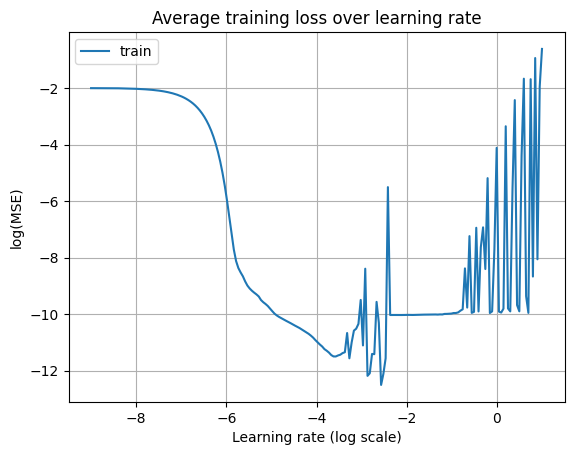

In [23]:
# Plotting the log MSE as a funtion of the learning rate
plt.plot(np.log10(lrs), np.log(train_losses), label = "train")
plt.xlabel("Learning rate (log scale)")
plt.ylabel("log(MSE)")
plt.title("Average training loss over learning rate" )
plt.grid()
plt.legend()

In [57]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 8*10**3,
         "lr": 1e-4,
         "gamma": .5,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}


use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])

# Loading Train / Test Data
hs_dataset = sabr_dataset
train_size, test_size = int(hs_dataset.shape[0]*0.9), int(hs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(hs_dataset, [train_size, hs_dataset.shape[0] - train_size])

train_loader = torch.utils.data.DataLoader(train_dataset, args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = SABR_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=500, gamma=args["gamma"]) # Deacreses the Learning rate by .5 every 500 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "ANN_weights/SABR_ANN.pt")
    

cuda
Train Epoch: 1 [0/89581 (0%)]	log Loss: -2.836094

Train set: Average log loss: -6.0662


Test set: Average loss: -9.3773

Current Learning rate 0.0001
Train Epoch: 2 [0/89581 (0%)]	log Loss: -9.337511

Train set: Average log loss: -9.6906


Test set: Average loss: -9.9785

Current Learning rate 0.0001
Train Epoch: 3 [0/89581 (0%)]	log Loss: -9.941213

Train set: Average log loss: -10.1446


Test set: Average loss: -10.2449

Current Learning rate 0.0001
Train Epoch: 4 [0/89581 (0%)]	log Loss: -10.209425

Train set: Average log loss: -10.3512


Test set: Average loss: -10.3806

Current Learning rate 0.0001
Train Epoch: 5 [0/89581 (0%)]	log Loss: -10.351527

Train set: Average log loss: -10.4786


Test set: Average loss: -10.4835

Current Learning rate 0.0001
Train Epoch: 6 [0/89581 (0%)]	log Loss: -10.472799

Train set: Average log loss: -10.5845


Test set: Average loss: -10.5962

Current Learning rate 0.0001
Train Epoch: 7 [0/89581 (0%)]	log Loss: -10.597168

Train set: Average l

In [14]:
print(F)


0.051341825514985236


## c) Training Heston-IV-ANN

### Use Brent to inverse price to implied volatility (IV)

In [17]:
from scipy import optimize

def calcimpliedvol(dataset):
    """
    Computes the implied volatilities using the brent method.
    dataset: numpy array containing moneyness, time to maturity, risk free interest rate and V/K.
    Returns a vector of implied volatilities.
    """
    money = np.array(dataset[0])
    T = np.array(dataset[1])
    r = np.array(dataset[2])
    marketoptionPrice = np.array(dataset[3])
    def bs_price(sigma):
      d1 = ( np.log(money) + (r + 0.5 * sigma ** 2) * (T) ) / (sigma * np.sqrt(T))
      d2 = d1 - sigma*np.sqrt(T)
      value_moyeness = money * norm.cdf(d1) - np.exp(-r * (T)) * norm.cdf(d2) 
      fx = value_moyeness - marketoptionPrice
      return fx
    return optimize.brentq(bs_price, -1, 1, maxiter=100)



### Generate data and add IV to get the final training data set

In [23]:
sample, hs_prices = Heston_LHS_data_generator(n = 10**5)

# Combine required inputs for Brent
brent_input = np.concatenate([sample[:, [0, 1, 2]], hs_prices], axis=1)  # shape (n, 4)

#print("brent_input shape:", brent_input.shape)

# Apply Brent row by row
implied_vols = np.array([
    calcimpliedvol(row) for row in brent_input
])

#print("V_0 ......... [{:.2f}, {:.2f}]".format(sample[:,7].min(), sample[:,7].max()))
print("------ ANN OUTPUT ------")

print("Black-scholes IV sigma.......... [{:.2f}, {:.2f}]".format(implied_vols.min(), implied_vols.max()))

# Filter out NaNs
valid_idx = ~np.isnan(implied_vols)
sample = sample[valid_idx]
implied_vols = implied_vols[valid_idx]

# Recombine into final dataset (input + IV target)
final_dataset = np.concatenate([sample, implied_vols.reshape(-1, 1)], axis=1)

# Convert to torch Tensor
hs_dataset = torch.FloatTensor(final_dataset)


------ INPUT ------
S/K.......... [0.61, 1.39]
Tau.......... [0.06, 2.99]
r............ [0.01, 0.04]
Corr ........ [-0.89, -0.01]
Kappa........ [0.41, 2.99]
V_bar........ [0.02, 0.49]
Gamma........ [0.02, 0.79]
V_0 ......... [0.06, 0.49]
------ OUTPUT ------
V/K.......... [-0.00, 0.77]
------ ANN OUTPUT ------
Black-scholes IV sigma.......... [0.00, 0.74]


### Training of the ANN

In [21]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 8*10**3,
         "lr": 1e-4,
         "gamma": .5,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}


use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])

# Loading Train / Test Data
hs_dataset = hs_dataset
train_size, test_size = int(hs_dataset.shape[0]*0.9), int(hs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(hs_dataset, [train_size, hs_dataset.shape[0] - train_size])

train_loader = torch.utils.data.DataLoader(train_dataset, args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = Heston_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=500, gamma=args["gamma"]) # Deacreses the Learning rate by .5 every 500 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "ANN_weights/HESTON_IV_ANN.pt")
    

cuda
Train Epoch: 1 [0/77478 (0%)]	log Loss: -0.814654

Train set: Average log loss: -2.9490


Test set: Average loss: -4.9763

Current Learning rate 0.0001
Train Epoch: 2 [0/77478 (0%)]	log Loss: -4.947230

Train set: Average log loss: -5.3119


Test set: Average loss: -5.9893

Current Learning rate 0.0001
Train Epoch: 3 [0/77478 (0%)]	log Loss: -5.962725

Train set: Average log loss: -6.6269


Test set: Average loss: -7.2201

Current Learning rate 0.0001
Train Epoch: 4 [0/77478 (0%)]	log Loss: -7.247884

Train set: Average log loss: -7.4967


Test set: Average loss: -7.8282

Current Learning rate 0.0001
Train Epoch: 5 [0/77478 (0%)]	log Loss: -7.836086

Train set: Average log loss: -7.9839


Test set: Average loss: -8.2073

Current Learning rate 0.0001
Train Epoch: 6 [0/77478 (0%)]	log Loss: -8.222159

Train set: Average log loss: -8.3124


Test set: Average loss: -8.5013

Current Learning rate 0.0001
Train Epoch: 7 [0/77478 (0%)]	log Loss: -8.528742

Train set: Average log loss: -8.

Training WIDE 3.275045119604548e-08 VS in the article 8.04e-09


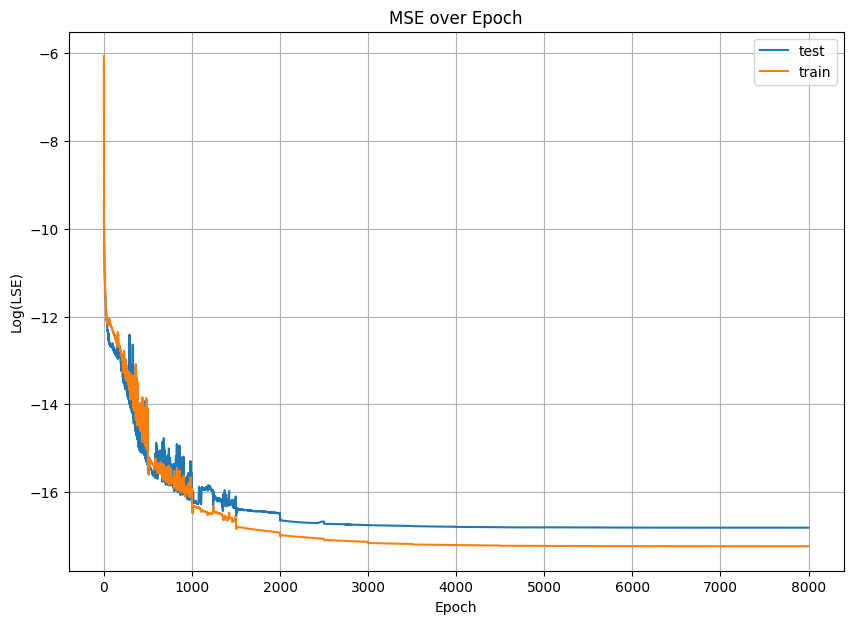

In [58]:
# Plotting log(MSE) as a function of epochs
plt.figure(figsize=(10,7))
plt.plot( np.log(test_losses), label = "test")
plt.plot( np.log(train_losses), label = "train")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Log(LSE)")
plt.title("MSE over Epoch" )
plt.grid()
print("Training WIDE {} VS in the article 8.04e-09".format(train_losses[-1]) )

In [59]:
# Loading model
device = 'cuda'
loaded_SABR_ANN = SABR_ANN().to(device)
PATH = "ANN_weights/SABR_ANN.pt"
loaded_SABR_ANN.load_state_dict(torch.load(PATH))
loaded_SABR_ANN.eval()


SABR_ANN(
  (fc1): Linear(in_features=7, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=200, bias=True)
  (fc3): Linear(in_features=200, out_features=200, bias=True)
  (fc4): Linear(in_features=200, out_features=200, bias=True)
  (fc5): Linear(in_features=200, out_features=1, bias=True)
)

In [60]:
# printing train and test erros MSE, MAE, MAPE, R2.
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_SABR_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_SABR_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 3.274896e-08
MAE 1.339271e-04
MAPE 1.843620e-01
R2 9.992513e-01
-----------Test scores----------------
MSE 4.995131e-08
MAE 1.547653e-04
MAPE 1.488520e-01
R2 9.989339e-01


## d) Prediction
#### Load the ANN

In [18]:
# Loading model
device = 'cuda'
loaded_Heston_IV_ANN = Heston_ANN().to(device)
PATH = "ANN_weights/HESTON_IV_ANN.pt"
loaded_Heston_IV_ANN.load_state_dict(torch.load(PATH))
loaded_Heston_IV_ANN.eval()


Heston_ANN(
  (fc1): Linear(in_features=8, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=200, bias=True)
  (fc3): Linear(in_features=200, out_features=200, bias=True)
  (fc4): Linear(in_features=200, out_features=200, bias=True)
  (fc5): Linear(in_features=200, out_features=1, bias=True)
)

#### This table shows similar trained forward performance as shown in Table (4) from [1]

In [25]:
# printing train and test erros MSE, MAE, MAPE, R2.
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_IV_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_IV_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 6.363491e-07
MAE 6.223580e-04
MAPE 1.346766e-03
R2 9.999357e-01
-----------Test scores----------------
MSE 1.323949e-06
MAE 7.818849e-04
MAPE 1.727188e-03
R2 9.998636e-01


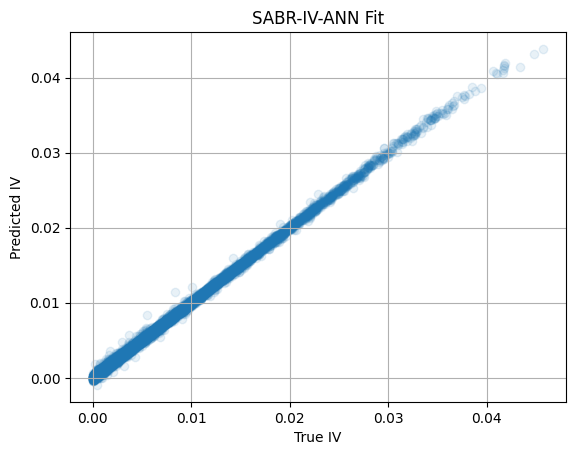

In [81]:

plt.scatter(targets, outputs, alpha=0.1)
plt.xlabel("True IV")
plt.ylabel("Predicted IV")
plt.title("SABR-IV-ANN Fit")
plt.grid(True)
plt.show()


# 2) Backward pass

### Reference parameters

In [19]:
# Section 4.1.1 in [1]
T = 2 
S0 = 100
kappa = 0.1
gamma = 0.1  
v_bar = 0.1
rho = -0.75
v0 = 0.05
r = 0.05

### CaNN search space

In [62]:
alpha_bounds = (0.01, 0.08)   # vol level
beta_bounds  = (0.30, 0.99)
rho_bounds   = (-0.90, 0.90)
nu_bounds    = (0.06, 0.70)


In [105]:
sample_sabr, sabr_vols = SABR_LHS_data_generator_pysabr_moneyness(
    n=200_000,
    seed=42,
    vol_cap=1e9,   # effectively no cap
)

v = sabr_vols[:, 0]
print("min/max:", v.min(), v.max())
print("share > 1.0:", (v > 1.0).mean())
print("quantiles:", np.quantile(v, [0.001, 0.01, 0.5, 0.99, 0.999]))


------ INPUT (SABR) ------
m (K/F)...... [0.800, 1.200]
K............ [0.000810, 0.071923]
T............ [0.250, 10.000]
F............ [0.001000, 0.060000]
alpha........ [0.001000, 0.100000]
beta......... [0.300, 1.000]
rho.......... [-0.900, 0.900]
nu........... [0.050, 0.800]
------ OUTPUT ------
normal vol... [0.000005, 0.053528]
Kept 199040 / 200000 rows after filtering
min/max: 4.501667944925627e-06 0.05352830809956976
share > 1.0: 0.0
quantiles: [3.53934817e-05 1.28824934e-04 4.22520097e-03 2.98870942e-02
 3.86835139e-02]


In [54]:
option_expiries = ['1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '15Y']  # 7 maturities
F0 = 0.02   # 2% forward
shift0 = 0.0

n_strikes = 5
x_levels = np.linspace(-0.01, 0.01, n_strikes)  # K-F in [-1%, 1%]


In [55]:
def generate_sabr_market_surface(theta_true):
    # theta_true = (alpha, beta, rho, nu) or (alpha, rho, nu) with fixed beta0
    market_quotes = []
    for label in option_expiries:
        T = year_frac_from_maturity_label(label)
        if len(theta_true) == 3:
            alpha, rho, nu = theta_true
            beta = beta0
        else:
            alpha, beta, rho, nu = theta_true

        sabr = Hagan2002NormalSABR(
            f      = F0,
            shift  = shift0,
            t      = T,
            v_atm_n = alpha,  # you’re treating alpha as ATM normal vol
            beta   = beta,
            rho    = rho,
            volvol = nu,
        )

        for x in x_levels:
            K = F0 + x
            iv = sabr.normal_vol(K)
            market_quotes.append((x, T, iv))

    market_quotes = np.array(market_quotes)  # shape (35, 3) = [x, T, iv]
    return market_quotes


In [63]:
# Parameter ranges for the 5D Heston grid (Table 6 in [1])
rho_min,  rho_max  = -0.75, -0.25
kappa_min,kappa_max=  0.5,   1.0
vbar_min, vbar_max =  0.15,  0.35
gamma_min,gamma_max=  0.3,  0.5
v0_min,   v0_max   =  0.15,  0.35

# 5 equidistant values for each parameter within the specified bounds
rho_vals   = np.linspace(rho_min,   rho_max,   5)
kappa_vals = np.linspace(kappa_min, kappa_max, 5)
vbar_vals  = np.linspace(vbar_min,  vbar_max,  5)
gamma_vals = np.linspace(gamma_min, gamma_max, 5)
v0_vals    = np.linspace(v0_min,    v0_max,    5)

# Build full 5D grid: shape (5, 5, 5, 5, 5)
R, K, VBAR, G, V0 = np.meshgrid(rho_vals, kappa_vals, vbar_vals, gamma_vals, v0_vals, indexing="ij")

# Stack into a (3125, 5) array:
# each row = one parameter vector [rho, kappa, v̄, gamma, v0]
param_grid = np.stack([R, K, VBAR, G, V0], axis=-1).reshape(-1, 5)

print(param_grid.shape)  # (3125, 5)


(3125, 5)


In [64]:
alpha_min, alpha_max  = 0.01, 0.08 # vol level
beta_min, beta_max=  0.30, 0.99
rho_min, rho_max =  -0.90, 0.90
nu_min, nu_max=  0.06, 0.70

# 5 equidistant values for each parameter within the specified bounds
alpha_vals = np.linspace(alpha_min, alpha_max,   5)
beta_vals = np.linspace(beta_min, beta_max, 5)
rho_vals  = np.linspace(rho_min, rho_max,  5)
nu_vals  = np.linspace(nu_min, nu_max,  5)

# Build full 4D grid: shape (5, 5, 5, 5) = 625 combinations
A, B, RHO, NU = np.meshgrid(alpha_vals, beta_vals, rho_vals, nu_vals, indexing="ij")

# Stack into a (625, 4) array:
# each row = [alpha, beta, rho, nu]
param_grid_sabr = np.stack([A, B, RHO, NU], axis=-1).reshape(-1, 4)

print(param_grid_sabr.shape)  # (625, 4)

(625, 4)


## a) Calibration of all 4 SABR parameters




### Objective function

In [33]:
# Equation (19) in [1]

def calibration_objective(theta, inputs, market_iv, iv_ann):
    # theta: [rho, kappa, vbar, gamma, v0]
    # inputs: [moneyness, maturity, r] fixed per quote
    input_tensor = torch.tensor(np.column_stack([
        inputs,  # shape (N, 3)
        np.tile(theta, (inputs.shape[0], 1))
    ]), dtype=torch.float32).to(device)

    with torch.no_grad():
        pred_iv = iv_ann(input_tensor).cpu().numpy().flatten()

    reg = (1e-6 * np.sum(np.abs(theta)))
    return np.mean((pred_iv - market_iv) ** 2) + reg


In [70]:
def sabr_calibration_objective(theta, inputs, market_iv, iv_ann):
    """
    SABR analogue of Equation (19) in [1].

    Parameters
    ----------
    theta : array-like, shape (4,)
        SABR parameters [alpha, beta, rho, nu].
    inputs : array-like, shape (N, 3)
        Fixed quote locations [x, T, F] for each of the N quotes.
    market_iv : array-like, shape (N,)
        "Market" normal implied volatilities for these quotes.
    iv_ann : torch.nn.Module
        Trained SABR-IV-ANN taking [x, T, F, alpha, beta, rho, nu] as input.
    """
    # theta: [alpha, beta, rho, nu]
    # inputs: [x, T, F] fixed per quote
    N = inputs.shape[0]
    theta_tiled = np.tile(theta, (N, 1))  # shape (N, 4)

    # concatenate quote-location inputs and parameter vector
    model_inputs = np.column_stack([inputs, theta_tiled])  # shape (N, 7)

    input_tensor = torch.tensor(model_inputs, dtype=torch.float32).to(device)

    with torch.no_grad():
        pred_iv = iv_ann(input_tensor).cpu().numpy().flatten()

    # same simple L1-regularization as in Heston case
    # reg = 1e-6 * np.sum(np.abs(theta))
    return np.mean((pred_iv - market_iv) ** 2) # + reg


In [66]:
iv_ann = loaded_SABR_ANN         # the trained ANN will be passed in the DE function


### Synthetic calibration data  (five equally spaced points between the lower and upper bound for each parameter, 5^4 = 625 combinations in total) 

In [ ]:
# Fixed (moneyness, maturity) grid: 5 × 7 = 35 synthetic market quotes per case
moneyness = np.linspace(0.85, 1.15, 5)
maturity  = np.linspace(0.5, 2.0, 7)
S0 = 100.0
r  = 0.03

# Storage for parameter errors and objective values over all test cases
all_abs_errors_5 = []
all_J_values_5 = []  

for i, (rho, kappa, vbar, gamma, v0) in enumerate(param_grid, start=1):
    # True Heston parameter vector for this test case
    theta_true = np.array([rho, kappa, vbar, gamma, v0])

    # --- generate 35 synthetic "market" IV quotes for theta_true ---
    market_quotes = []
    for tau in maturity:
        for m in moneyness:
            # Heston call price under theta_true
            price = call_option_Heston_moy(500, 12, r, tau, kappa, gamma, vbar, v0, rho, m)
            # Invert price to implied volatility
            iv    = calcimpliedvol([m, tau, r, price])
            # Store tuple (m, tau, r, iv)
            market_quotes.append((m, tau, r, iv))

    market_quotes = np.array(market_quotes)
    inputs    = market_quotes[:, :3]   # (m, tau, r)
    market_iv = market_quotes[:, 3]    # IVs

    # --- run DE calibration on CaNN parameter bounds (Table 6 region) ---
    result = differential_evolution(
        lambda theta: calibration_objective(theta, inputs, market_iv, iv_ann),
        bounds=[
            (rho_min,   rho_max),
            (kappa_min, kappa_max),
            (vbar_min,  vbar_max),
            (gamma_min, gamma_max),
            (v0_min,    v0_max),
        ],
        strategy="best1bin",
        popsize=10,      # 10 × number_of_parameters, as in the paper
    )

    theta_hat = result.x
    abs_err = np.abs(theta_hat - theta_true)
    all_abs_errors_5.append(abs_err)
    all_J_values_5.append(result.fun)

    #if i <= 3:  # just to see a few
    #    print(f"Case {i}/{len(param_grid)}")
    #    print(" true:", np.round(theta_true, 6))
    #    print(" hat: ", np.round(theta_hat, 6))
    #    print(" abs: ", np.round(abs_err, 6))
    #    print(" MSE: ", result.fun)

all_abs_errors_5 = np.array(all_abs_errors_5)
#print("Mean abs error over 3125 cases:", all_abs_errors_5.mean(axis=0))

In [72]:
def sabr_calibration_objective_parts(theta, inputs, market_iv, iv_ann, device):
    N = inputs.shape[0]
    theta_tiled = np.tile(theta, (N, 1))
    model_inputs = np.column_stack([inputs, theta_tiled])
    x = torch.as_tensor(model_inputs, dtype=torch.float32, device=device)

    with torch.no_grad():
        pred_iv = iv_ann(x).squeeze(-1).detach().cpu().numpy()

    mse = np.mean((pred_iv - market_iv)**2)
    reg = 1e-6 * np.sum(np.abs(theta))
    return mse, reg, mse + reg


In [73]:
rhos = np.linspace(-0.9, 0.9, 19)
vals = []
for r in rhos:
    th = theta_true.copy()
    th[2] = r
    mse, _, _ = sabr_calibration_objective_parts(th, inputs, market_iv, iv_ann, device)
    vals.append(mse)

print(list(zip(rhos, vals)))


[(-0.9, 3.7299831272890456e-08), (-0.8, 4.2166403052025844e-08), (-0.7, 4.305001748180199e-08), (-0.6, 4.0776987278837126e-08), (-0.5, 3.057325728328706e-08), (-0.4, 2.3841232349909757e-08), (-0.29999999999999993, 2.0958946724173414e-08), (-0.19999999999999996, 1.7255248129769373e-08), (-0.09999999999999998, 1.8839512121314258e-08), (0.0, 2.214881609023773e-08), (0.09999999999999998, 1.3093398628777805e-08), (0.20000000000000007, 7.968889966287327e-09), (0.30000000000000016, 1.5453379852126965e-08), (0.4, 1.905999575987763e-08), (0.5000000000000001, 1.6384681827158436e-08), (0.6, 1.2034465323800708e-08), (0.7000000000000001, 5.905923486943379e-09), (0.8000000000000002, 4.583656680128785e-09), (0.9, 2.8867218945228504e-08)]


In [75]:
# Fixed (strike offset, expiry) grid: 5 × 7 = 35 synthetic SABR quotes per case
F0    = 0.02                                   # forward swap rate (fixed)
shift = 0.0
m_grid = np.linspace(0.9, 1.1, 5)           # K - F in [-10%, 10%]
T_grid = np.linspace(0.5, 10.0, 7)             # expiries in years

# Storage for parameter errors and objective values over all test cases
all_abs_errors_4 = []
all_J_values_4 = []  

for i, (alpha, beta, rho, nu) in enumerate(param_grid_sabr, start=1):
    # True Heston parameter vector for this test case
    theta_true = np.array([alpha, beta, rho, nu])

    # --- generate 35 synthetic "market" IV quotes for theta_true ---
    market_quotes = []
    for T in T_grid:
        for m in m_grid:
            K = m * F0
            iv = hagan_normal.normal_vol(
                k=K, f=F0, t=T,
                alpha=alpha, beta=beta, rho=rho, volvol=nu
            )
            market_quotes.append((m, T, F0, iv))

    market_quotes = np.array(market_quotes)
    inputs    = market_quotes[:, :3]   # (x, T, F0)
    market_iv = market_quotes[:, 3]    # IVs

    # --- run DE calibration on CaNN parameter bounds (Table 6 region) ---
    result = differential_evolution(
        lambda theta: sabr_calibration_objective(theta, inputs, market_iv, iv_ann),
        bounds=[
            (alpha_min,   alpha_max),
            (beta_min, beta_max),
            (rho_min,  rho_max),
            (nu_min, nu_max),            
        ],
        strategy="best1bin",
        popsize=10,      # 10 × number_of_parameters, as in the paper
    )

    theta_hat = result.x
    abs_err = np.abs(theta_hat - theta_true)
    all_abs_errors_4.append(abs_err)
    all_J_values_4.append(result.fun)

    if i <= 3:  # just to see a few
        print(f"Case {i}/{len(param_grid_sabr)}")
        print(" true:", np.round(theta_true, 6))
        print(" hat: ", np.round(theta_hat, 6))
        print(" abs: ", np.round(abs_err, 6))
        print(" MSE: ", result.fun)

    #J_true = sabr_calibration_objective(theta_true, inputs, market_iv, iv_ann)
    # after DE:
    #J_hat  = sabr_calibration_objective(theta_hat,  inputs, market_iv, iv_ann)

    #print("J_true:", J_true, "J_hat:", J_hat)


all_abs_errors_4 = np.array(all_abs_errors_4)
#print("Mean abs error over 3125 cases:", all_abs_errors_5.mean(axis=0))

Case 1/625
 true: [ 0.01  0.3  -0.9   0.06]
 hat:  [ 0.064427  0.780706 -0.37647   0.34605 ]
 abs:  [0.054427 0.480706 0.52353  0.28605 ]
 MSE:  7.838878061521628e-09
Case 2/625
 true: [ 0.01  0.3  -0.9   0.22]
 hat:  [ 0.042041  0.67488  -0.646442  0.43299 ]
 abs:  [0.032041 0.37488  0.253558 0.21299 ]
 MSE:  1.8360674613552501e-09
Case 3/625
 true: [ 0.01  0.3  -0.9   0.38]
 hat:  [ 0.044737  0.686089 -0.769     0.498562]
 abs:  [0.034737 0.386089 0.131    0.118562]
 MSE:  2.1488113904573477e-09


In [ ]:
# Fixed (strike offset, expiry) grid: 5 × 7 = 35 synthetic SABR quotes per case
F0    = 0.02                                   # forward swap rate (fixed)
shift = 0.0
m_grid = np.linspace(0.9, 1.1, 5)           # K - F in [-1%, 1%]
T_grid = np.linspace(0.5, 10.0, 7)             # expiries in years

# Storage for parameter errors and objective values over all test cases
all_abs_errors_4 = []
all_J_values_4 = []  

for i, (alpha, beta, rho, nu) in enumerate(param_grid_sabr, start=1):
    # True Heston parameter vector for this test case
    theta_true = np.array([alpha, beta, rho, nu])

    # --- generate 35 synthetic "market" IV quotes for theta_true ---
    market_quotes = []
    for T in T_grid:
        # SABR model for this expiry and parameter set
        sabr = Hagan2002NormalSABR(
            f       = F0,
            shift   = shift,
            t       = T,
            v_atm_n = alpha,     # here alpha plays the role of ATM normal vol
            beta    = beta,
            rho     = rho,
            volvol  = nu,
        )
        for m in m_grid:
            K  = m * F0
            iv = sabr.normal_vol(K)    # direct implied normal vol (no Brent)
            # Store tuple (m, T, F0, iv) – analogous structure to (m, tau, r, iv)
            market_quotes.append((m, T, F0, iv))

    market_quotes = np.array(market_quotes)
    inputs    = market_quotes[:, :3]   # (x, T, F0)
    market_iv = market_quotes[:, 3]    # IVs

    # --- run DE calibration on CaNN parameter bounds (Table 6 region) ---
    result = differential_evolution(
        lambda theta: sabr_calibration_objective(theta, inputs, market_iv, iv_ann),
        bounds=[
            (alpha_min,   alpha_max),
            (beta_min, beta_max),
            (rho_min,  rho_max),
            (nu_min, nu_max),            
        ],
        strategy="best1bin",
        popsize=10,      # 10 × number_of_parameters, as in the paper
    )

    theta_hat = result.x
    abs_err = np.abs(theta_hat - theta_true)
    all_abs_errors_4.append(abs_err)
    all_J_values_4.append(result.fun)

    if i <= 3:  # just to see a few
        print(f"Case {i}/{len(param_grid_sabr)}")
        print(" true:", np.round(theta_true, 6))
        print(" hat: ", np.round(theta_hat, 6))
        print(" abs: ", np.round(abs_err, 6))
        print(" MSE: ", result.fun)

    J_true = sabr_calibration_objective(theta_true, inputs, market_iv, iv_ann)
    # after DE:
    J_hat  = sabr_calibration_objective(theta_hat,  inputs, market_iv, iv_ann)

    print("J_true:", J_true, "J_hat:", J_hat)


all_abs_errors_4 = np.array(all_abs_errors_4)
#print("Mean abs error over 3125 cases:", all_abs_errors_5.mean(axis=0))

Case 1/625
 true: [ 0.01  0.3  -0.9   0.06]
 hat:  [3.37150e-02 3.01975e-01 1.14000e-04 6.00000e-02]
 abs:  [0.023715 0.001975 0.900114 0.      ]
 MSE:  4.517892754871396e-07
J_true: 4.6225408547318845e-05 J_hat: 4.517892754871396e-07
Case 2/625
 true: [ 0.01  0.3  -0.9   0.22]
 hat:  [ 3.66400e-02  3.24498e-01 -1.58000e-04  6.01720e-02]
 abs:  [0.02664  0.024498 0.899842 0.159828]
 MSE:  4.7063703447499186e-07
J_true: 4.8801834112381123e-05 J_hat: 4.7063703447499186e-07
Case 3/625
 true: [ 0.01  0.3  -0.9   0.38]
 hat:  [ 3.64360e-02  3.22766e-01 -2.52000e-04  6.04250e-02]
 abs:  [0.026436 0.022766 0.899748 0.319575]
 MSE:  4.940607124288338e-07
J_true: 5.1582348573603814e-05 J_hat: 4.940607124288338e-07
J_true: 6.370595225284696e-05 J_hat: 9.316143465412605e-06
J_true: 7.976442119510877e-05 J_hat: 1.8717852441042718e-05
J_true: 4.564105389911137e-05 J_hat: 4.4916064849341723e-07
J_true: 4.8770615499760814e-05 J_hat: 4.591447475476926e-07
J_true: 4.823223529935081e-05 J_hat: 4.6866626

KeyboardInterrupt: 

### Averaged performance of the backward pass of the Heston-CaNN (5 parameters)

In [44]:
F=0.02; m=1.01; K=m*F; T=2.0
alpha=0.03; beta=0.5; rho=-0.7; nu=0.4

v_train = sabr.normal_vol(F, K, T, alpha, beta, rho, nu)

v_calib = Hagan2002NormalSABR(
    f=F, shift=0.0, t=T,
    v_atm_n=alpha, beta=beta, rho=rho, volvol=nu
).normal_vol(K)

print(v_train, v_calib, abs(v_train-v_calib))


TypeError: normal_vol() takes 2 positional arguments but 8 were given

In [46]:
import inspect
print(inspect.signature(hagan_normal.normal_vol))


(k, f, t, alpha, beta, rho, volvol)


In [76]:
param_names = ["|rho-rho*|     =", "|kappa-kappa*| =", "|vbar-vbar*|   =", "|gamma-gamma*| =", "|v0-v0*|       ="]
mean_abs = all_abs_errors_5.mean(axis=0)  # shape (5,)


print("Absolute deviation from Theta*:\n")
for name, val in zip(param_names, mean_abs):
    print("  {} {:e}".format(name, val))


NameError: name 'all_abs_errors_5' is not defined

In [80]:
param_names = ["|alpha-alpha*|     =", "|beta-beta*| =", "|rho-rho*|   =", "|nu-nu*| ="]
mean_abs = all_abs_errors_4.mean(axis=0)  # shape (5,)


print("Absolute deviation from Theta*:\n")
for name, val in zip(param_names, mean_abs):
    print("  {} {:e}".format(name, val))

print("Mean abs error over 625 cases:", all_abs_errors_4.mean(axis=0))

Absolute deviation from Theta*:

  |alpha-alpha*|     = 1.778557e-02
  |beta-beta*| = 1.223074e-01
  |rho-rho*|   = 1.947271e-01
  |nu-nu*| = 9.573578e-02
Mean abs error over 625 cases: [0.01778557 0.12230737 0.19472706 0.09573578]


In [78]:
all_J_values = np.array(all_J_values_4)   # each entry is MJ for one surface
MJ_mean = all_J_values.mean()
N = market_iv.shape[0]  # 35
J_theta = MJ_mean * N

print("J(Theta): {:.6e}".format(J_theta))
print("MJ      : {:.6e}".format(MJ_mean))


J(Theta): 3.784387e-07
MJ      : 1.081253e-08


## b) Calibration of only 3 SABR parameters




### (beta fixed)

In [ ]:
def calibration_objective_3(theta_3, inputs, market_iv, iv_ann, kappa_true, v0_true):
    """
    theta_3 : [rho, vbar, gamma]
    kappa_true, v0_true : fixed from the current test case
    inputs : (N, 3) with (m, tau, r)
    """
    rho, vbar, gamma = theta_3
    m   = inputs[:, 0].astype(np.float32)
    tau = inputs[:, 1].astype(np.float32)
    r   = inputs[:, 2].astype(np.float32)
    N   = inputs.shape[0]

    X = np.column_stack([
        m,
        tau,
        r,
        np.full(N, rho,         dtype=np.float32),
        np.full(N, kappa_true, dtype=np.float32),
        np.full(N, vbar,       dtype=np.float32),
        np.full(N, gamma,      dtype=np.float32),
        np.full(N, v0_true,    dtype=np.float32),
    ])

    x_tensor = torch.from_numpy(X).to(device)
    with torch.no_grad():
        pred_iv = iv_ann(x_tensor).cpu().numpy().ravel()

    diff = pred_iv - market_iv
    mse  = np.mean(diff**2)
    return mse 


In [27]:
bounds_3 = [
    (rho_min,  rho_max),
    (vbar_min, vbar_max),
    (gamma_min,gamma_max),
]

all_abs_errors_3 = []
all_J_values_3 = []  

for i, (rho_t, kappa_t, vbar_t, gamma_t, v0_t) in enumerate(param_grid, start=1):
    # ----- generate market quotes for the true parameter set -----
    market_quotes = []
    for tau in maturity:
        for m in moneyness:
            price = call_option_Heston_moy(500, 12, r, tau, kappa_t, gamma_t, vbar_t, v0_t, rho_t, m)
            iv    = calcimpliedvol([m, tau, r, price])
            market_quotes.append((m, tau, r, iv))

    market_quotes = np.array(market_quotes)
    inputs    = market_quotes[:, :3]
    market_iv = market_quotes[:, 3]

    # ----- DE only over (rho, vbar, gamma); kappa_t, v0_t fixed -----
    res = differential_evolution(
        lambda theta_3: calibration_objective_3(theta_3, inputs, market_iv, iv_ann,
                                               kappa_true=kappa_t, v0_true=v0_t),
        bounds=bounds_3,
        strategy="best1bin",
        popsize=15,      

    )

    theta_hat_3 = res.x
    theta_true_3 = np.array([rho_t, vbar_t, gamma_t])
    abs_err = np.abs(theta_hat_3 - theta_true_3)
    all_abs_errors_3.append(abs_err)
    all_J_values_3.append(result.fun)

    #if i <= 3:
    #    print(f"Case {i}/{len(param_grid)}")
    #    print(" true (rho,vbar,gamma):", theta_true_3)
    #    print(" hat  (rho,vbar,gamma):", theta_hat_3)
    #    print(" abs err:", abs_err)
    #    print(" MSE:    ", res.fun)

all_abs_errors_3 = np.array(all_abs_errors_3)
#mean_abs_err = all_abs_errors_3.mean(axis=0)
#print("Mean abs error [rho, vbar, gamma]:", mean_abs_err_3)


In [87]:
def sabr_calibration_objective_3(theta3, inputs, market_iv, iv_ann, beta_true):
    """
    SABR analogue of Equation (19) in [1].

    Parameters
    ----------
    theta : array-like, shape (4,)
        SABR parameters [alpha, beta, rho, nu].
    inputs : array-like, shape (N, 3)
        Fixed quote locations [x, T, F] for each of the N quotes.
    market_iv : array-like, shape (N,)
        "Market" normal implied volatilities for these quotes.
    iv_ann : torch.nn.Module
        Trained SABR-IV-ANN taking [x, T, F, alpha, beta, rho, nu] as input.
    """
    # theta: [alpha, beta, rho, nu]
    # inputs: [x, T, F] fixed per quote
    N = inputs.shape[0]

    alpha, rho, nu = theta3

    beta_col  = np.full((N,1), beta_true)
    alpha_col = np.full((N,1), alpha)
    rho_col   = np.full((N,1), rho)
    nu_col    = np.full((N,1), nu)

    # inputs should be [m, T, F] (your code uses m)
    model_inputs = np.column_stack([inputs, alpha_col, beta_col, rho_col, nu_col])  # (N,7)

    input_tensor = torch.tensor(model_inputs, dtype=torch.float32).to(device)
    with torch.no_grad():
        pred_iv = iv_ann(input_tensor).cpu().numpy().flatten()

    return np.mean((pred_iv - market_iv)**2)

In [ ]:
# Fixed (strike offset, expiry) grid: 5 × 7 = 35 synthetic SABR quotes per case
F0    = 0.02                                   # forward swap rate (fixed)
m_grid = np.linspace(0.9, 1.1, 5)           # K - F in [-10%, 10%]
T_grid = np.linspace(0.5, 10.0, 7)             # expiries in years

# Storage for parameter errors and objective values over all test cases
all_abs_errors_3 = []
all_J_values_3 = []  

for i, (alpha, beta, rho, nu) in enumerate(param_grid_sabr, start=1):
    # True Heston parameter vector for this test case
    theta_true = np.array([alpha, beta, rho, nu])

    # --- generate 35 synthetic "market" IV quotes for theta_true ---
    market_quotes = []
    for T in T_grid:
        for m in m_grid:
            K = m * F0
            iv = hagan_normal.normal_vol(
                k=K, f=F0, t=T,
                alpha=alpha, beta=beta, rho=rho, volvol=nu
            )
            market_quotes.append((m, T, F0, iv))

    market_quotes = np.array(market_quotes)
    inputs    = market_quotes[:, :3]   # (x, T, F0)
    market_iv = market_quotes[:, 3]    # IVs

    # --- run DE calibration on CaNN parameter bounds (Table 6 region) ---
    result = differential_evolution(
        lambda theta: sabr_calibration_objective(theta, inputs, market_iv, iv_ann),
        bounds=[
            (alpha_min,   alpha_max),
            (beta_min, beta_max),
            (rho_min,  rho_max),
            (nu_min, nu_max),            
        ],
        strategy="best1bin",
        popsize=10,      # 10 × number_of_parameters, as in the paper
    )

    theta_hat = result.x
    abs_err = np.abs(theta_hat - theta_true)
    all_abs_errors_4.append(abs_err)
    all_J_values_4.append(result.fun)

    if i <= 3:  # just to see a few
        print(f"Case {i}/{len(param_grid_sabr)}")
        print(" true:", np.round(theta_true, 6))
        print(" hat: ", np.round(theta_hat, 6))
        print(" abs: ", np.round(abs_err, 6))
        print(" MSE: ", result.fun)

    #J_true = sabr_calibration_objective(theta_true, inputs, market_iv, iv_ann)
    # after DE:
    #J_hat  = sabr_calibration_objective(theta_hat,  inputs, market_iv, iv_ann)

    #print("J_true:", J_true, "J_hat:", J_hat)


all_abs_errors_4 = np.array(all_abs_errors_4)
#print("Mean abs error over 3125 cases:", all_abs_errors_5.mean(axis=0))

In [ ]:
bounds_sabr_3 = [
    (alpha_min, alpha_max),
    (rho_min,   rho_max),
    (nu_min,    nu_max),
]


all_abs_errors_3 = []
all_J_values_3 = []

for i, (alpha_t, beta_t, rho_t, nu_t) in enumerate(param_grid_sabr, start=1):

    # --- market quotes (use beta_t) ---
    market_quotes = []
    for T in T_grid:
        for m in m_grid:
            K = m * F0
            iv = hagan_normal.normal_vol(
                k=K, f=F0, t=T,
                alpha=alpha_t, beta=beta_t, rho=rho_t, volvol=nu_t
            )
            market_quotes.append((m, T, F0, iv))

    market_quotes = np.array(market_quotes)
    inputs    = market_quotes[:, :3]   # (m, T, F)
    market_iv = market_quotes[:, 3]

    # --- DE only over (alpha, rho, nu); beta_t fixed like Heston fixed params ---
    res = differential_evolution(
        lambda th3: sabr_calibration_objective_3(th3, inputs, market_iv, iv_ann, beta_true=beta_t),
        bounds=bounds_sabr_3,
        strategy="best1bin",
        popsize=10,
    )

    theta_hat_3  = res.x                      # [alpha_hat, rho_hat, nu_hat]
    theta_true_3 = np.array([alpha_t, rho_t, nu_t])

    abs_err = np.abs(theta_hat_3 - theta_true_3)
    all_abs_errors_3.append(abs_err)
    all_J_values_3.append(res.fun)

    if i <= 3:
        print(f"Case {i}/{len(param_grid_sabr)} (beta fixed={beta_t:.3f})")
        print(" true [a,rho,nu]:", np.round(theta_true_3, 6))
        print(" hat  [a,rho,nu]:", np.round(theta_hat_3, 6))
        print(" abs  [a,rho,nu]:", np.round(abs_err, 6))
        print(" MSE:", res.fun)

all_abs_errors_3 = np.array(all_abs_errors_3)


Case 1/625 (beta fixed=0.300)
 true [a,rho,nu]: [ 0.01 -0.9   0.06]
 hat  [a,rho,nu]: [0.01     0.338079 0.081077]
 abs  [a,rho,nu]: [0.       1.238079 0.021077]
 MSE: 3.005072247526691e-08
Case 2/625 (beta fixed=0.300)
 true [a,rho,nu]: [ 0.01 -0.9   0.22]
 hat  [a,rho,nu]: [ 0.01     -0.834991  0.207458]
 abs  [a,rho,nu]: [0.       0.065009 0.012542]
 MSE: 2.4225509747501812e-08
Case 3/625 (beta fixed=0.300)
 true [a,rho,nu]: [ 0.01 -0.9   0.38]
 hat  [a,rho,nu]: [ 0.01     -0.845477  0.214582]
 abs  [a,rho,nu]: [0.       0.054523 0.165418]
 MSE: 4.223494138760241e-08


### Averaged performance of the backward pass of the SABR-CaNN (3 parameters)

In [92]:
param_names = ["|alpha-alpha*| =", "|rho-rho*|     =", "|nu-nu*|       ="]
mean_abs = all_abs_errors_3.mean(axis=0)  # shape (5,)

print("Absolute deviation from Theta*:\n")
for name, val in zip(param_names, mean_abs):
    print("  {} {:e}".format(name, val))


Absolute deviation from Theta*:

  |alpha-alpha*| = 1.402585e-03
  |rho-rho*|     = 2.062349e-01
  |nu-nu*|       = 9.666376e-02


In [ ]:
all_J_values_3 = np.array(all_J_values_3)   # each entry is MJ for one surface
MJ_mean = all_J_values_3.mean()
N = market_iv.shape[0]  # 35
J_theta = MJ_mean * N

print("J(Theta): {:.6e}".format(J_theta))
print("MJ      : {:.6e}".format(MJ_mean))


J(Theta): 5.972039e-07
MJ      : 1.706297e-08


In [95]:
mean_err   = all_abs_errors_3.mean(axis=0)
median_err = np.median(all_abs_errors_3, axis=0)

print("Mean abs err  [alpha, rho, nu]:", mean_err)
print("Median abs err[alpha, rho, nu]:", median_err)

names = ["alpha", "rho", "nu"]
for j, name in enumerate(names):
    print(f"{name:5s}  mean={mean_err[j]:.6e}  median={median_err[j]:.6e}")


Mean abs err  [alpha, rho, nu]: [0.00140259 0.20623486 0.09666376]
Median abs err[alpha, rho, nu]: [0.00068117 0.12982651 0.07473882]
alpha  mean=1.402585e-03  median=6.811674e-04
rho    mean=2.062349e-01  median=1.298265e-01
nu     mean=9.666376e-02  median=7.473882e-02


In [96]:
nu_true = np.array([nu_t for (alpha_t, beta_t, rho_t, nu_t) in param_grid_sabr])

bins = np.array([0.05, 0.15, 0.30, 0.50, 0.80])  # adjust to your nu grid/range
idx = np.digitize(nu_true, bins, right=True)

for b in range(1, len(bins)+1):
    mask = (idx == b)
    if mask.sum() == 0:
        continue
    m = all_abs_errors_3[mask].mean(axis=0)
    med = np.median(all_abs_errors_3[mask], axis=0)
    print(f"nu* in bucket {b} (count={mask.sum()}): mean={m}, median={med}")

counts, edges = np.histogram(nu_true, bins=bins)
print("counts:", counts)
print("edges :", edges)


nu* in bucket 1 (count=125): mean=[0.00126421 0.41156908 0.10368565], median=[0.00052003 0.36968454 0.09188778]
nu* in bucket 2 (count=125): mean=[0.00141928 0.23463672 0.08699048], median=[0.00060582 0.20596344 0.07988444]
nu* in bucket 3 (count=125): mean=[0.00146051 0.16157302 0.09592046], median=[0.00072625 0.12355035 0.07362563]
nu* in bucket 4 (count=250): mean=[0.00143446 0.11169773 0.0983611 ], median=[0.00078148 0.07826241 0.06194298]
counts: [125 125 125 250]
edges : [0.05 0.15 0.3  0.5  0.8 ]


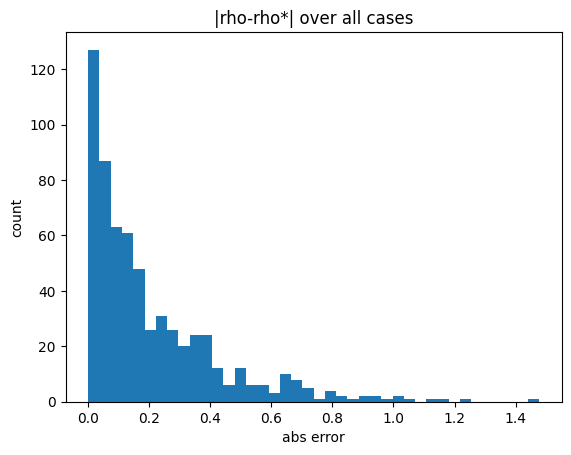

In [97]:

rho_err = all_abs_errors_3[:, 1]

plt.figure()
plt.hist(rho_err, bins=40)
plt.title("|rho-rho*| over all cases")
plt.xlabel("abs error")
plt.ylabel("count")
plt.show()


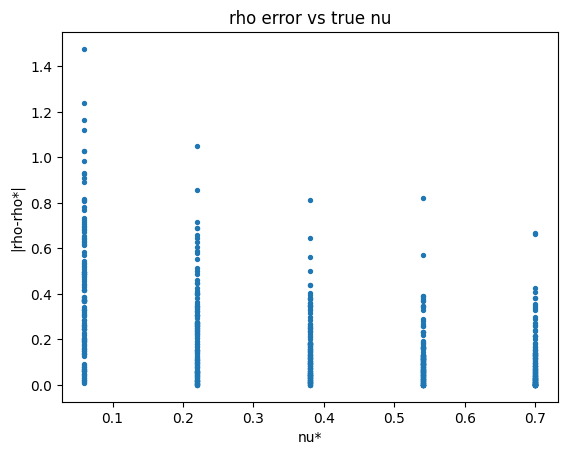

In [98]:
plt.figure()
plt.scatter(nu_true, rho_err, s=8)
plt.xlabel("nu*")
plt.ylabel("|rho-rho*|")
plt.title("rho error vs true nu")
plt.show()
